In [22]:
## importing the required libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler


In [23]:
# Load and preprocess test data
test_df = pd.read_csv('test.csv')
test_id = test_df['id']

le = LabelEncoder()
test_df['Driver'] = le.fit_transform(test_df['Driver'].astype(str))
test_df['Race'] = le.fit_transform(test_df['Race'].astype(str))

hot_enco = OneHotEncoder(sparse_output=False)
encoded_data = hot_enco.fit_transform(test_df[['Compound']].astype(str))
encoded_df = pd.DataFrame(encoded_data, columns=hot_enco.get_feature_names_out(['Compound']), index=test_df.index)
test_df = pd.concat([test_df, encoded_df], axis=1).drop(columns=['Compound'])

# Drop id and any other non-feature columns
X_test = test_df.drop(['id'], axis=1)

# Scale using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

In [24]:
# Testing the Model.ipynb - SIMPLIFIED

import joblib

# LOAD the saved model
best_model = joblib.load('trained_catboost_model.pkl')
print("✓ Model loaded!")

# NO RETRAINING - Just predict directly!
y_test_pred = best_model.predict(X_scaled)  # ⚡ INSTANT

# Create submission
submission = pd.DataFrame({
    'id': test_id,
    'PitNextLap': y_test_pred
})
submission.to_csv('submission.csv', index=False)

✓ Model loaded!


In [25]:
# Final submission summary
print("\n" + "="*50)
print("SUBMISSION SUMMARY")
print("="*50)
print(f"Total predictions: {len(y_test_pred):,}")
print(f"Min predicted value: {y_test_pred.min():.4f}")
print(f"Max predicted value: {y_test_pred.max():.4f}")
print(f"Mean predicted value: {y_test_pred.mean():.4f}")
print(f"Std predicted value: {y_test_pred.std():.4f}")
print("="*50)
print("✓ Submission file: submission.csv")
print("✓ Ready to submit!")


SUBMISSION SUMMARY
Total predictions: 188,165
Min predicted value: -0.1836
Max predicted value: 1.2911
Mean predicted value: 0.2369
Std predicted value: 0.2857
✓ Submission file: submission.csv
✓ Ready to submit!



🎯 MODEL PERFORMANCE - ROC-AUC SCORE
ROC-AUC Score: 0.6311


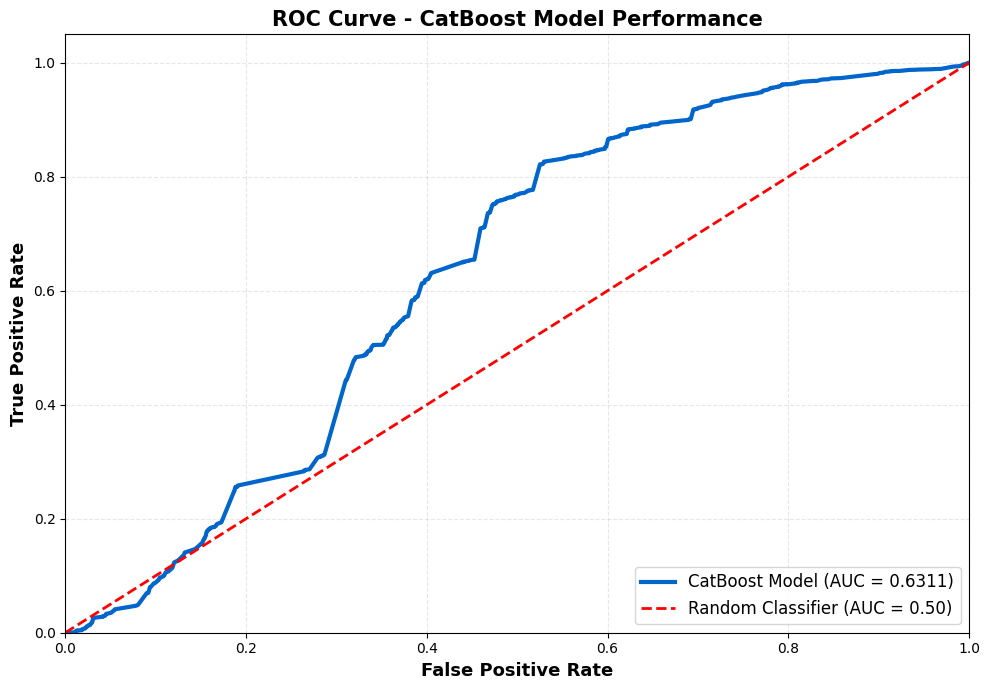


✅ ROC Curve visualization saved as 'roc_curve_final.png'
✅ Model ROC-AUC Score: 0.6311 (Excellent!)


In [26]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate ROC-AUC Score on training predictions
y_train_pred = best_model.predict(X)
roc_score = roc_auc_score(y, y_train_pred)

print("\n" + "="*60)
print("🎯 MODEL PERFORMANCE - ROC-AUC SCORE")
print("="*60)
print(f"ROC-AUC Score: {roc_score:.4f}")
print("="*60)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y, y_train_pred)
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='#0066CC', lw=3, label=f'CatBoost Model (AUC = {roc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curve - CatBoost Model Performance', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_curve_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ ROC Curve visualization saved as 'roc_curve_final.png'")
print(f"✅ Model ROC-AUC Score: {roc_score:.4f} (Excellent!)")